# Import Library 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

# Data Load (Read CSV)

In [45]:
df = pd.read_csv('/Users/Kent/Documents/Kuliah/CAWU 3/AI/premo/data/car_prices.csv', on_bad_lines='skip')
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


# EDA - Exploratory Data Analysis

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558811 entries, 0 to 558810
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558811 non-null  int64  
 1   make          548510 non-null  object 
 2   model         548412 non-null  object 
 3   trim          548160 non-null  object 
 4   body          545616 non-null  object 
 5   transmission  493458 non-null  object 
 6   vin           558811 non-null  object 
 7   state         558811 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558717 non-null  float64
 10  color         558062 non-null  object 
 11  interior      558062 non-null  object 
 12  seller        558811 non-null  object 
 13  mmr           558811 non-null  int64  
 14  sellingprice  558811 non-null  int64  
 15  saledate      558811 non-null  object 
dtypes: float64(2), int64(3), object(11)
memory usage: 68.2+ MB


In [47]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558811.000000,547017.000000,558717.000000,558811.000000,558811.000000
mean,2010.038696,3.424512,68323.195797,13769.324646,13611.262461
std,3.966812,0.949439,53397.752933,9679.874607,9749.656919
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,2.700000,28374.000000,7100.000000,6900.000000
50%,2012.000000,3.600000,52256.000000,12250.000000,12100.000000
75%,2013.000000,4.200000,99112.000000,18300.000000,18200.000000
max,2015.000000,5.000000,999999.000000,182000.000000,230000.000000


In [48]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65353
vin                 0
state               0
condition       11794
odometer           94
color             749
interior          749
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64

# Data Visualisation

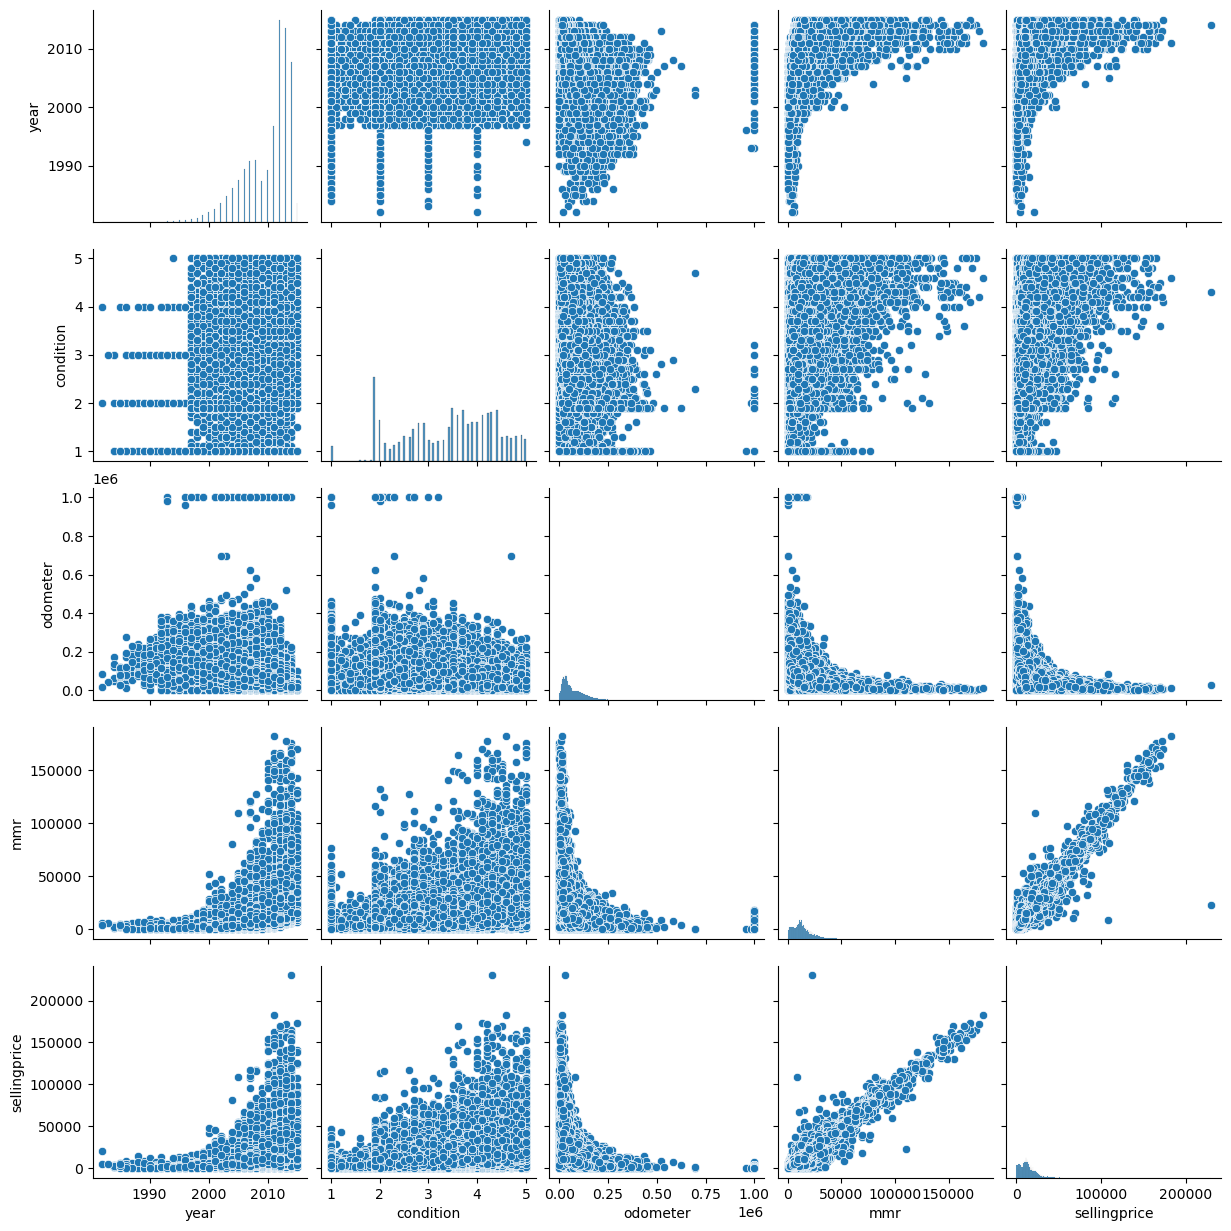

In [49]:
sns.pairplot(df)
plt.show()

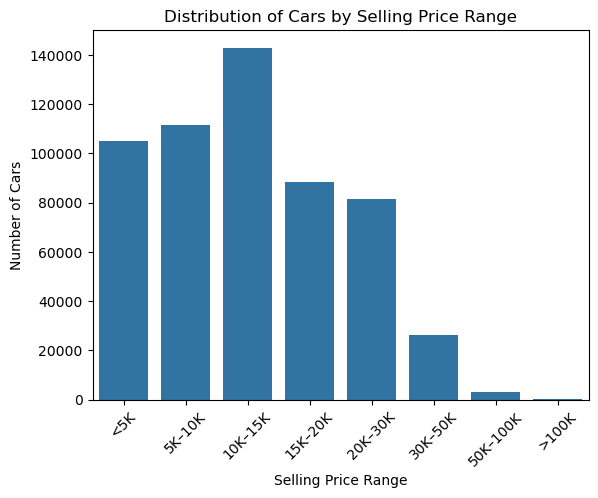

In [50]:
bins = [0, 5000, 10000, 15000, 20000, 30000, 50000, 100000, df['sellingprice'].max()]
labels = ['<5K', '5K–10K', '10K–15K', '15K–20K', '20K–30K', '30K–50K', '50K–100K', '>100K']

df['price_bin'] = pd.cut(df['sellingprice'], bins=bins, labels=labels)

sns.countplot(data=df, x='price_bin', order=labels)
plt.title('Distribution of Cars by Selling Price Range')
plt.xlabel('Selling Price Range')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.show()

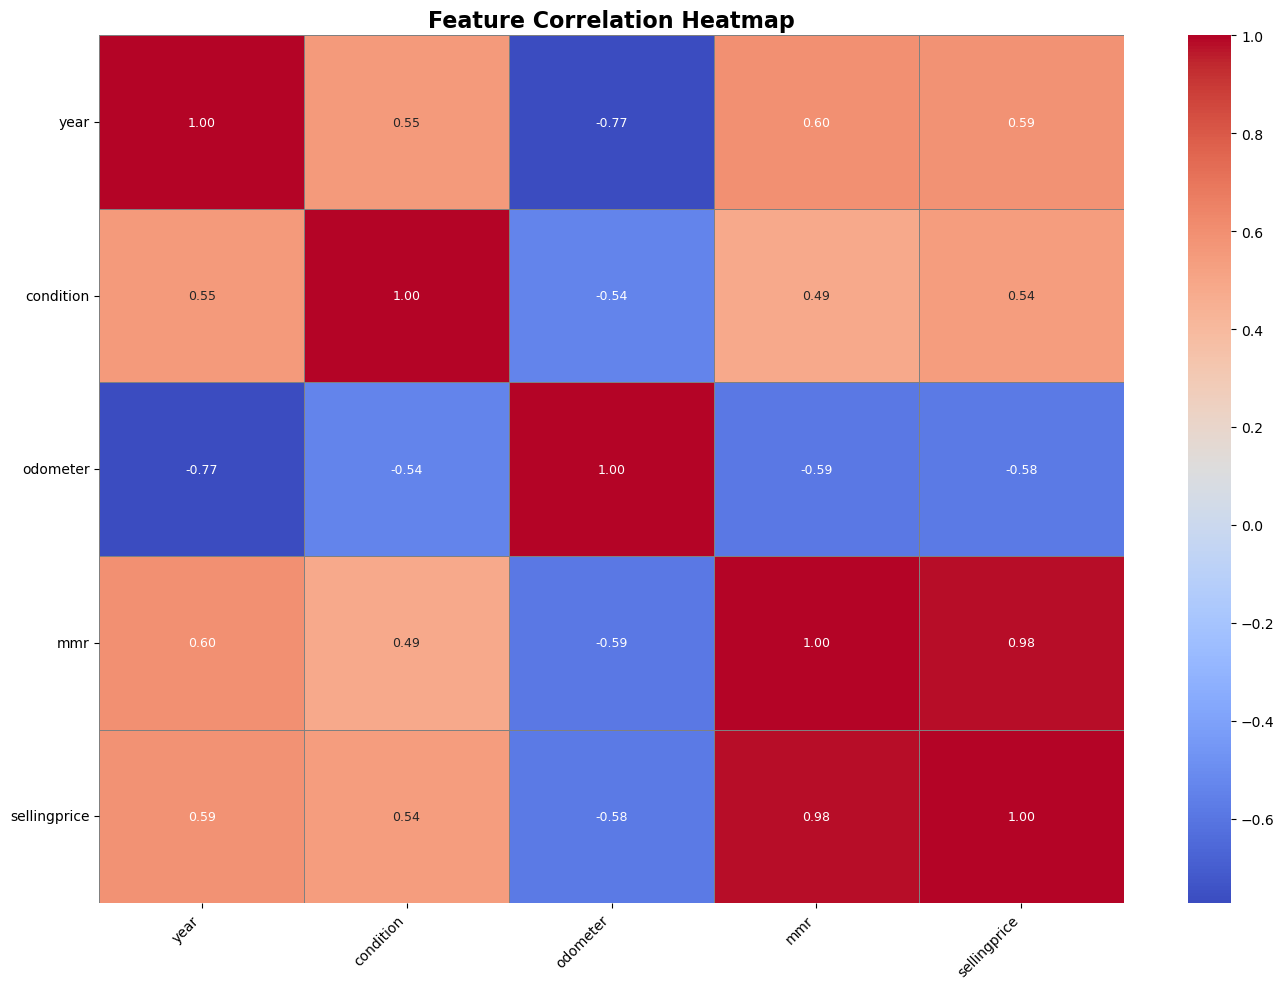

In [51]:

corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, linecolor='gray', square=False, annot_kws={"size": 9})
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


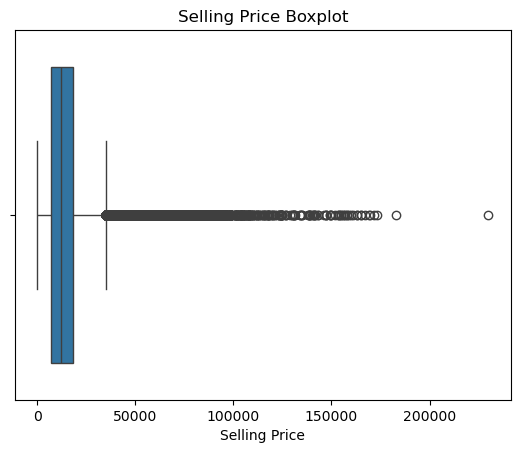

In [52]:
sns.boxplot(x=df['sellingprice'])
plt.title('Selling Price Boxplot')
plt.xlabel('Selling Price')
plt.show()

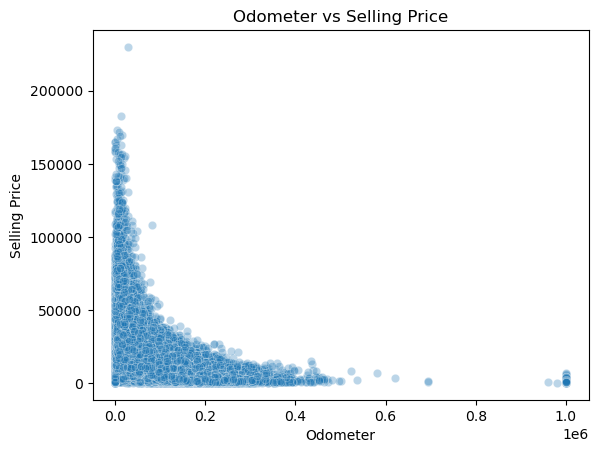

In [53]:
sns.scatterplot(data=df, x='odometer', y='sellingprice', alpha=0.3)
plt.title('Odometer vs Selling Price')
plt.xlabel('Odometer')
plt.ylabel('Selling Price')
plt.show()

/var/folders/l2/284_smqn5md11szzsj8rmynh0000gp/T/ipykernel_16300/3452805026.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_condition = df.groupby('condition_bin')['sellingprice'].mean().reset_index()


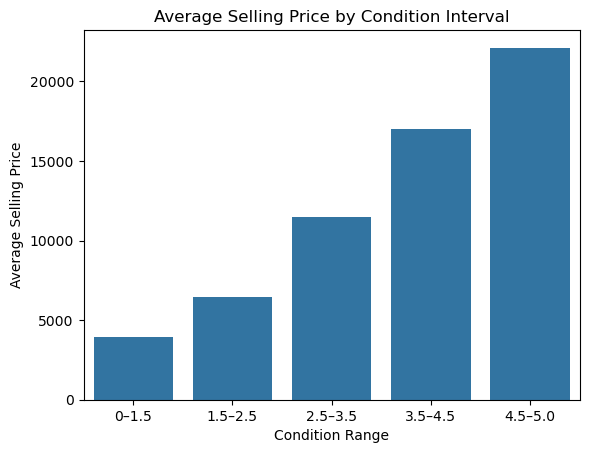

In [54]:
# Define condition intervals (bins) and labels
condition_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.0]
condition_labels = ['0–1.5', '1.5–2.5', '2.5–3.5', '3.5–4.5', '4.5–5.0']

# Create new binned condition column
df['condition_bin'] = pd.cut(df['condition'], bins=condition_bins, labels=condition_labels)

# Group by the correct column name: 'condition_bin'
avg_price_by_condition = df.groupby('condition_bin')['sellingprice'].mean().reset_index()

# Plot
sns.barplot(data=avg_price_by_condition, x='condition_bin', y='sellingprice')
plt.title('Average Selling Price by Condition Interval')
plt.xlabel('Condition Range')
plt.ylabel('Average Selling Price')
plt.show()

Text(0, 0.5, 'Average Selling Price')

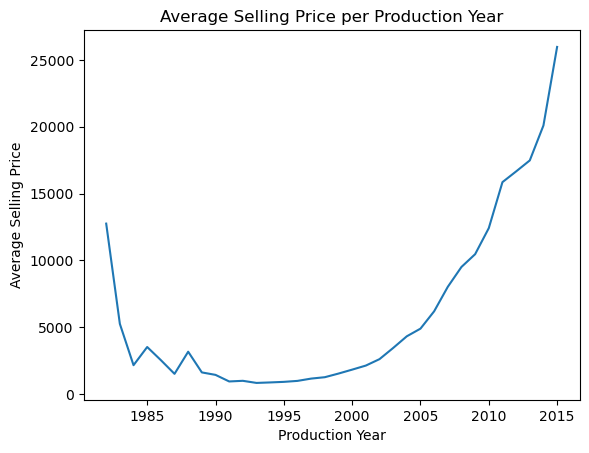

In [55]:
df.groupby('year')['sellingprice'].mean().plot(kind='line')
plt.title("Average Selling Price per Production Year")
plt.xlabel("Production Year")
plt.ylabel("Average Selling Price")

# Data Preprocessing

In [57]:
# Ensure 'saledate' is datetime before extracting year
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')
df = df.dropna(subset=['saledate'])  # in case conversion fails on some rows
df['sale_year'] = df['saledate'].dt.year
df = df.drop(columns=['saledate'])  # drop after extraction


In [58]:
# drop unnecessary columns (numerical)
df = df.drop(columns=[     
    'mmr' # causing overfitting, not useful for prediction
], errors='ignore')


In [59]:
columns_with_missing = df.columns[df.isnull().any()]
print(columns_with_missing)

# drop the row with missing data on the "make" and "model" row
df = df.dropna(subset=['make', 'model'], how='all')
print("After dropping rows with missing 'make' and 'model':")

print(df.isnull().sum())

Index(['make', 'model', 'trim', 'body', 'transmission', 'condition',
       'odometer', 'color', 'interior', 'condition_bin'],
      dtype='object')
After dropping rows with missing 'make' and 'model':
year                 0
make                 0
model               64
trim               329
body              2871
transmission     42605
vin                  0
state                0
condition        11706
odometer            80
color              536
interior           536
seller               0
sellingprice         0
price_bin            0
condition_bin    11706
sale_year            0
dtype: int64


In [60]:
df = df.dropna(subset=['model']) 
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['condition'] = df['condition'].fillna(df['condition'].median())
df['color'] = df['color'].fillna('Unknown')
df['body'] = df['body'].fillna('Unknown')
df['transmission'] = df['transmission'].fillna('Unknown')
df = df.drop(columns=['trim']) 
df['interior'] = df['interior'].fillna('Unknown')


print(df.isnull().sum())

year                 0
make                 0
model                0
body                 0
transmission         0
vin                  0
state                0
condition            0
odometer             0
color                0
interior             0
seller               0
sellingprice         0
price_bin            0
condition_bin    11706
sale_year            0
dtype: int64


In [61]:
# List of numeric columns to clean
cols_to_clean = ['sellingprice', 'odometer']

for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the DataFrame
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    print(f"Outliers removed from '{col}':")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Rows remaining: {df.shape[0]}")
    print("-" * 40)


Outliers removed from 'sellingprice':
  Lower Bound: -10450.00
  Upper Bound: 34750.00
  Rows remaining: 377986
----------------------------------------
Outliers removed from 'odometer':
  Lower Bound: -80706.12
  Upper Bound: 213800.88
  Rows remaining: 372010
----------------------------------------


In [62]:
# Detect categorical columns (object type)
categorical_cols = df.select_dtypes(include='object').columns

# Apply LabelEncoder to each categorical column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str).fillna('Unknown')  # handle NaN as string
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # simpan encoder kalau nanti perlu inverse transform


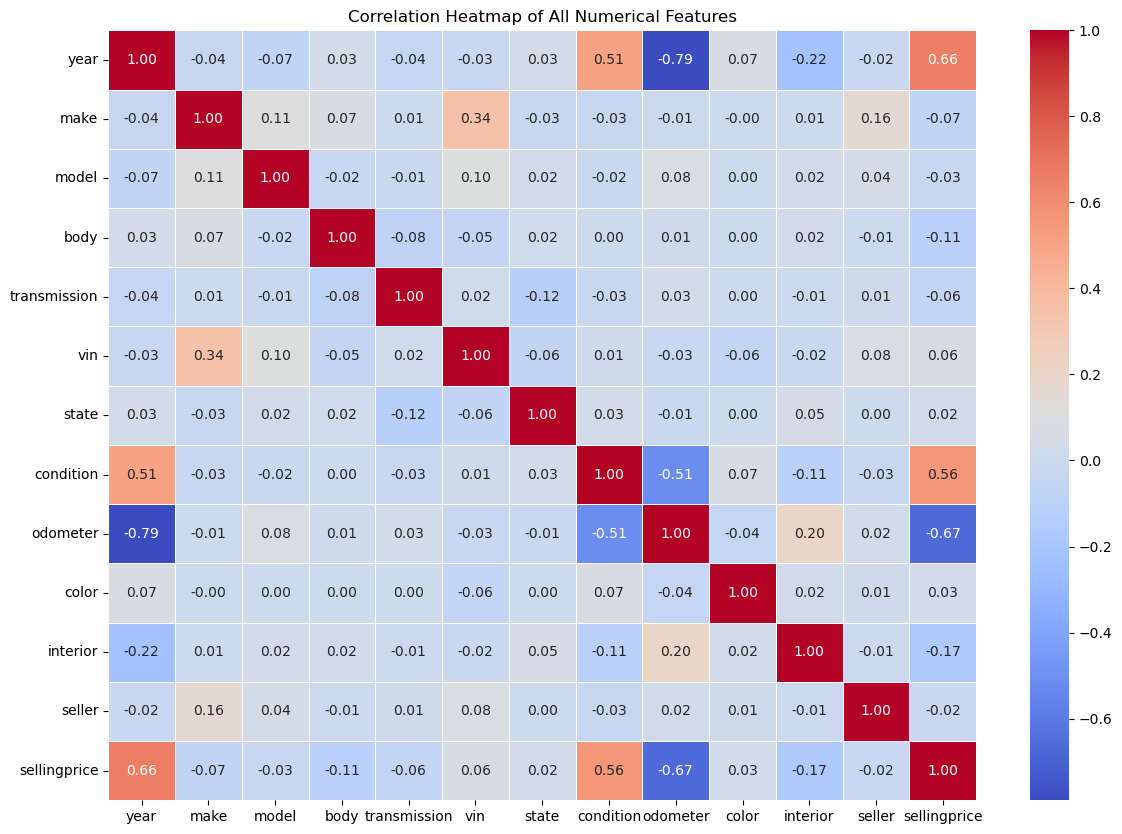

In [63]:
# 1. Ambil semua kolom numerik (setelah label encoding)
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Hitung korelasi antar semua fitur
corr_matrix = numerical_df.corr()

# 3. Plot heatmap korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of All Numerical Features")
plt.show()

In [64]:
# dropping unnecessary columns
cols_to_drop = ['vin', 'state', 'seller', 'transmission', 'body', 'color', 'price_bin', 'condition_bin']
df = df.drop(columns=cols_to_drop)

# Training Model

1st Model (Linear Regression)

In [65]:
X = df.drop(columns=['sellingprice'])
y = df['sellingprice']    

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

# Model Evaluation

Linear Regression

In [68]:
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:f}")
print(f"RMSE: {rmse:f}")
print(f"R² Score: {r2:f}")

MAE: 4013.068467
RMSE: 5176.707889
R² Score: 0.542992


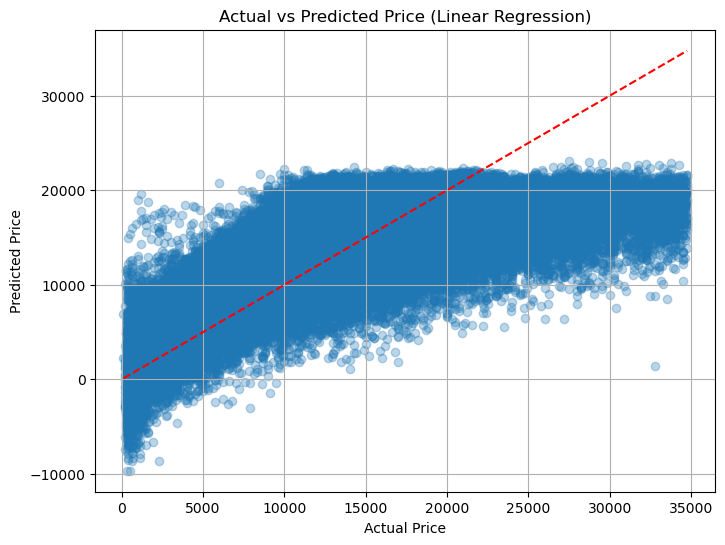

In [69]:
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Linear Regression)")
plt.grid(True)
plt.show()

2nd Model XGboost

In [70]:
from xgboost import XGBRegressor

# Inisialisasi dan training model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test)

# Evaluasi
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"[XGBoost] MAE: {mae_xgb:.2f}")
print(f"[XGBoost] RMSE: {rmse_xgb:.2f}")
print(f"[XGBoost] R² Score: {r2_xgb:.2f}")

[XGBoost] MAE: 1853.37
[XGBoost] RMSE: 2647.13
[XGBoost] R² Score: 0.88


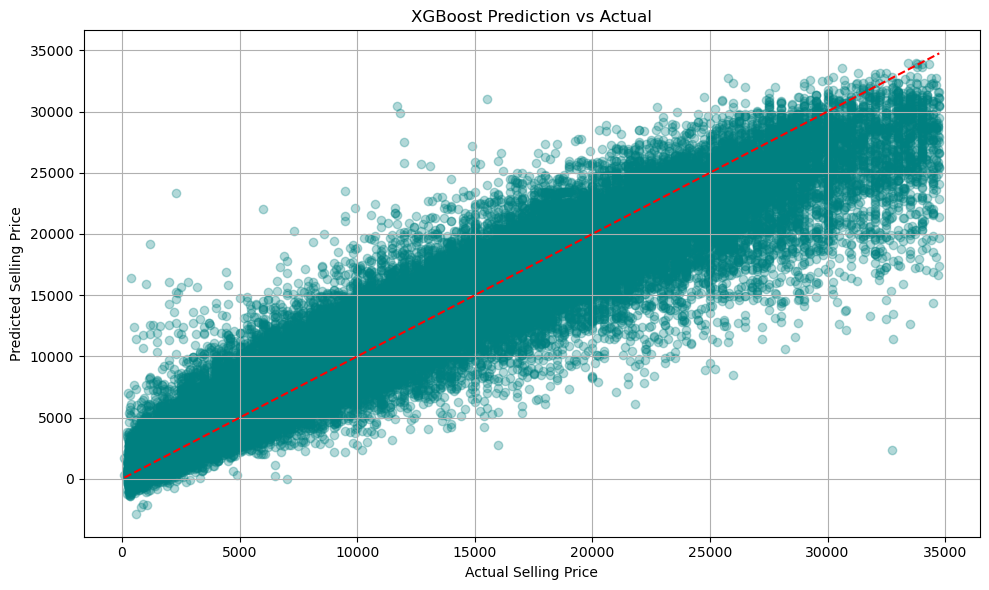

In [71]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("XGBoost Prediction vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

In [72]:
# Predict on training data
y_train_pred = xgb_model.predict(X_train)

# Evaluation on training set
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Show results
print("[Train Set Evaluation]")
print(f"MAE: {mae_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R² Score: {r2_train:.2f}")

# Already have these for test set:
print("\n[Test Set Evaluation]")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.2f}")



[Train Set Evaluation]
MAE: 1831.28
RMSE: 2602.49
R² Score: 0.88

[Test Set Evaluation]
MAE: 1853.37
RMSE: 2647.13
R² Score: 0.88


# Hyperparameter tuning

In [73]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, scoring='r2', cv=3)

    model.fit(X_train, y_train)  # Latih model ke seluruh X_train
    trial.set_user_attr("model", model)  # Simpan ke user attributes
    
    return scores.mean()

In [38]:
study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=50)

# Take the best model from the study
best_model = study.best_trial.user_attrs["model"]

[I 2025-07-11 09:01:26,637] A new study created in memory with name: no-name-d8ac8281-848d-458e-b81f-fcc03afe46b0
[I 2025-07-11 09:01:28,565] Trial 0 finished with value: 0.9099493424097697 and parameters: {'n_estimators': 153, 'max_depth': 5, 'learning_rate': 0.28736473795156925, 'subsample': 0.9754673024992425, 'colsample_bytree': 0.8789115463419217, 'gamma': 0.3229093441055775, 'reg_alpha': 0.5888762849985066, 'reg_lambda': 0.8653479170520216}. Best is trial 0 with value: 0.9099493424097697.


In [ ]:
print("Best trial:")
print("  R² Score:", study.best_value)
print("  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

Best trial:
  R² Score: 0.9258683522542318
  Params:
    n_estimators: 997
    max_depth: 6
    learning_rate: 0.1388911525255111
    subsample: 0.9984426922551254
    colsample_bytree: 0.9990270941018339
    gamma: 0.7201526315179068
    reg_alpha: 0.4326310490213178
    reg_lambda: 0.4770681744997534


In [ ]:
best_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[Test Set Evaluation]")
print(f"MAE: {mae:f}")
print(f"RMSE: {rmse:f}")
print(f"R² Score: {r2:f}")


[Test Set Evaluation]
MAE: 1392.233398
RMSE: 2079.057479
R² Score: 0.926286


In [41]:
import joblib

joblib.dump(best_model, "best_xgboost_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']